# forecast-spine

**Point-in-time correct evaluation of ERCOT day-ahead load forecasts.**

This notebook is the walkthrough of the submission. It runs the *actual
production spine* — the same `forecast_spine` package the CLI runs, the same
`sql/asof_join.sql`, the same gate code — over the assignment window, and shows
what it decides and why.

Nothing here is a parallel implementation for illustration. Every number is
computed by the shipped modules; re-executing the notebook re-derives all of
them.

## How this maps to the assignment

| Notebook | Assignment | Question it answers |
|---|---|---|
| [Architecture](#architecture) | — | How is the system put together? |
| [Part 0](#part-0) | Part 0 · Data | What did we retrieve, and what is missing? |
| [Part 1](#part-1) | Part 1 · As-of join | What was knowable at `T − 24h`? |
| [Part 2](#part-2) | Part 2 · Batch pipeline | Where did every row go, and does a rerun agree? |
| [Part 3](#part-3) | Part 3 · Eval gates | Should this run ship? |
| [Part 4](#part-4) | Part 4 · Memo | What is still open? |

Each part opens with an explicit block:

> **Asked** — what the assignment requires.
> **Decided** — what this repository does.
> **Traded** — what that choice costs.
> **Open** — what is unresolved, and how it would be resolved.

## The one rule

> Nothing used to produce a forecast for target hour `T` may have become
> available after `T − 24h`.

It is easy to state and easy to violate silently. A violation throws no error.
It produces a *better-looking* number. That asymmetry is the reason for
everything below.

<a id="architecture"></a>
## The production spine

Five stages, each with a single responsibility and an explicit failure mode.
The diagram is drawn from the module names it describes, so it cannot drift
from the code without the labels changing.

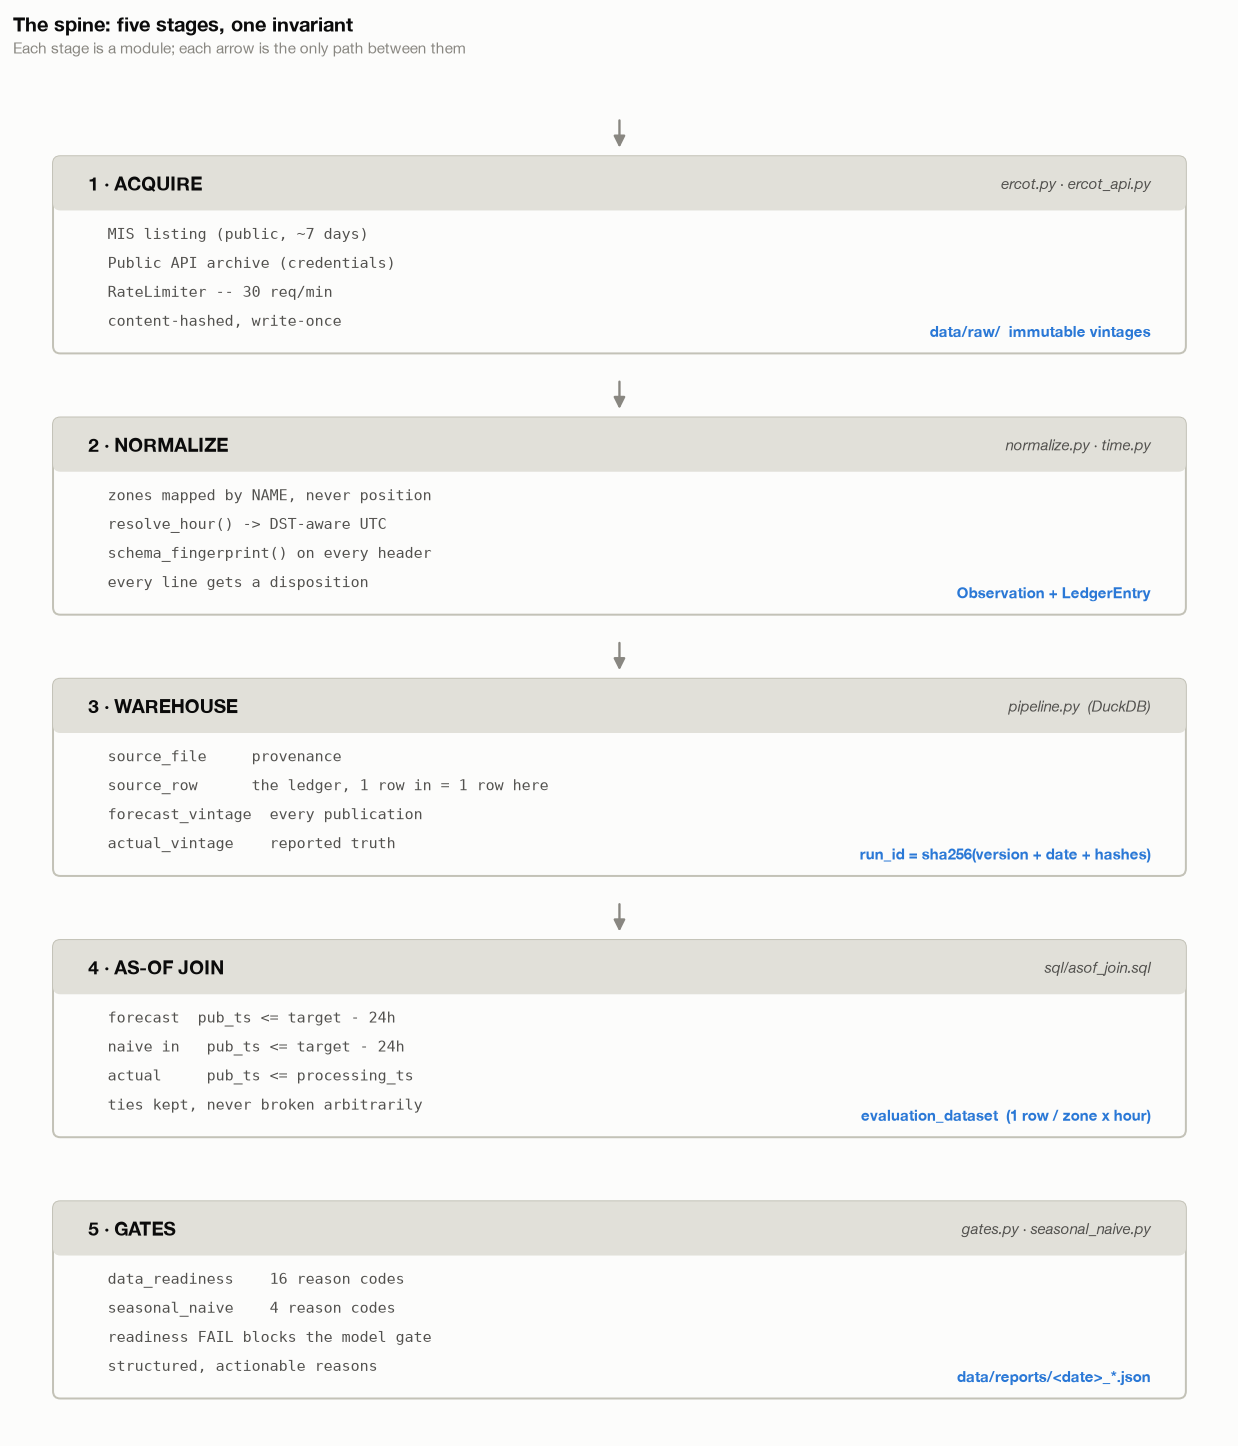

Entry point, identical to what a reviewer runs:
  forecast-spine run --processing-date 2026-03-24 --window-start 2026-02-22 --window-end 2026-03-23

Determinism: run_id is sha256(pipeline_version + processing_date + sorted
content hashes of every source file admitted). Same inputs -> same id ->
the same final state, because processing_ts hides anything published later.


In [1]:
from __future__ import annotations

import datetime as dt
import textwrap
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from forecast_spine import viz

viz.apply_style()
pd.set_option("display.width", 120)

STAGES = [
    ("1 · ACQUIRE", "ercot.py · ercot_api.py",
     ["MIS listing (public, ~7 days)", "Public API archive (credentials)",
      "RateLimiter -- 30 req/min", "content-hashed, write-once"],
     "data/raw/  immutable vintages"),
    ("2 · NORMALIZE", "normalize.py · time.py",
     ["zones mapped by NAME, never position", "resolve_hour() -> DST-aware UTC",
      "schema_fingerprint() on every header", "every line gets a disposition"],
     "Observation + LedgerEntry"),
    ("3 · WAREHOUSE", "pipeline.py  (DuckDB)",
     ["source_file     provenance", "source_row      the ledger, 1 row in = 1 row here",
      "forecast_vintage  every publication", "actual_vintage    reported truth"],
     "run_id = sha256(version + date + hashes)"),
    ("4 · AS-OF JOIN", "sql/asof_join.sql",
     ["forecast  pub_ts <= target - 24h", "naive in   pub_ts <= target - 24h",
      "actual     pub_ts <= processing_ts", "ties kept, never broken arbitrarily"],
     "evaluation_dataset  (1 row / zone x hour)"),
    ("5 · GATES", "gates.py · seasonal_naive.py",
     ["data_readiness    16 reason codes", "seasonal_naive    4 reason codes",
      "readiness FAIL blocks the model gate", "structured, actionable reasons"],
     "data/reports/<date>_*.json"),
]

fig, ax = plt.subplots(figsize=(9.6, 11.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, len(STAGES) * 2.12 + 0.45)
ax.axis("off")

for idx, (name, module, bullets, output) in enumerate(reversed(STAGES)):
    y = idx * 2.12 + 0.3
    ax.add_patch(FancyBboxPatch(
        (0.35, y), 9.3, 1.56, boxstyle="round,pad=0.02,rounding_size=0.06",
        facecolor=viz.SURFACE, edgecolor=viz.BASELINE, linewidth=1.1, zorder=2))
    ax.add_patch(FancyBboxPatch(
        (0.35, y + 1.16), 9.3, 0.40, boxstyle="round,pad=0.02,rounding_size=0.06",
        facecolor=viz.GRID, edgecolor="none", zorder=3))
    ax.text(0.62, y + 1.36, name, fontsize=10.5, weight="bold",
            color=viz.INK, va="center", zorder=4)
    ax.text(9.38, y + 1.36, module, fontsize=8.5, style="italic",
            color=viz.INK_SECONDARY, va="center", ha="right", zorder=4)
    for b, bullet in enumerate(bullets):
        ax.text(0.78, y + 0.94 - b * 0.235, bullet, fontsize=8.2,
                color=viz.INK_SECONDARY, va="center", family="monospace", zorder=4)
    ax.text(9.38, y + 0.16, output, fontsize=8.4, weight="bold",
            color=viz.SERIES_ACTUAL, va="center", ha="right", zorder=4)
    if idx:
        ax.add_patch(FancyArrowPatch(
            (5.0, y + 1.90), (5.0, y + 1.62), arrowstyle="-|>", mutation_scale=13,
            color=viz.INK_MUTED, linewidth=1.3, zorder=5))

viz.title(ax, "The spine: five stages, one invariant",
          "Each stage is a module; each arrow is the only path between them")
fig.tight_layout()
plt.show()

print("Entry point, identical to what a reviewer runs:")
print("  forecast-spine run --processing-date 2026-03-24 "
      "--window-start 2026-02-22 --window-end 2026-03-23")
print()
print("Determinism: run_id is sha256(pipeline_version + processing_date + sorted")
print("content hashes of every source file admitted). Same inputs -> same id ->")
print("the same final state, because processing_ts hides anything published later.")

### Building the run

This is the assignment window, built through the shipped pipeline. The only
notebook-specific choice is a scratch database so the committed warehouse is
not mutated by reading this file.

In [2]:
import tempfile

from forecast_spine import coverage, fixtures, gates, normalize, pipeline, seasonal_naive
from forecast_spine.time import hours_in_operating_date

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = REPO / "data" / "raw"
SQL = REPO / "sql" / "asof_join.sql"

# The assignment's window. Target hours 22 Feb - 23 Mar 2026 inclusive, Central;
# processing date 24 Mar because actuals for operating day D land on D+1.
PROCESSING_DATE = dt.date(2026, 3, 24)
WINDOW_START, WINDOW_END = dt.date(2026, 2, 22), dt.date(2026, 3, 23)
PUBLICATION_START = dt.date(2026, 2, 21)

LIVE = any(RAW.glob("load_forecast/*_csv.zip"))
if LIVE:
    raw_root = RAW
    context = pipeline.build_context(
        PROCESSING_DATE, raw_root,
        window_start=WINDOW_START, window_end=WINDOW_END,
    )
else:
    raw_root = fixtures.build("pass", Path(tempfile.mkdtemp()))
    context = pipeline.build_context(fixtures.processing_date_for("pass"), raw_root, window_days=1)
    print("LIVE VINTAGES NOT FOUND -- falling back to synthetic fixtures.\n"
          "Charts render, but the revision structure is absent by construction.\n"
          "Run `forecast-spine backfill` (credentials) or `acquire` (last ~7 days).\n")

con = pipeline.connect(Path(tempfile.mkdtemp()) / "notebook.duckdb")
results = pipeline.load(con, context)
evaluation_rows = pipeline.build_evaluation_dataset(con, context, SQL)

readiness = gates.data_readiness(con, context)
model_gate = gates.seasonal_naive_gate(con, context)
naive = seasonal_naive.evaluate(con, "naive")
ercot_model = seasonal_naive.evaluate(con, "ercot")

first_day, last_day = context.window_operating_dates
print(f"run_id            {context.run_id}")
print(f"processing date   {context.processing_date}  (visibility cutoff "
      f"{context.processing_ts_utc:%Y-%m-%d %H:%M} UTC)")
print(f"evaluation window {first_day} .. {last_day}   "
      f"({(last_day - first_day).days + 1} operating days)")
print(f"source files      {readiness.metrics['source_files']:,}")
print(f"source rows       {readiness.metrics['raw_source_rows']:,}")
print(f"evaluation rows   {evaluation_rows:,}")
print()
print(f"data_readiness    {readiness.status}")
print(f"seasonal_naive    {model_gate.status}    WAPE {naive.wape_pct:.2f}%")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

run_id            ae80e7096413957c6de9fafe9058c20b
processing date   2026-03-24  (visibility cutoff 2026-03-25 05:00 UTC)
evaluation window 2026-02-22 .. 2026-03-23   (30 operating days)
source files      775
source rows       1,132,967
evaluation rows   5,752

data_readiness    FAIL
seasonal_naive    FAIL    WAPE 8.65%


<a id="part-0"></a>
# Part 0 · Data

> **Asked** — retrieve NP3-565-CD (type 14837, seven-day load forecast by model
> and weather zone) and NP6-345-CD (type 13101, actual system load by weather
> zone). Preserve when each vintage became available. Implement a live
> retrieval path with runtime credentials. *State what you could and could not
> retrieve.*
>
> **Decided** — two retrieval paths against one on-disk layout. `acquire` reads
> the public MIS listing and needs no credentials but only reaches back ~7 days.
> `backfill` reads the authenticated Public API archive and reaches the
> assignment window. Both write content-hashed, write-once files to `data/raw/`,
> so the rest of the system cannot tell which fetched a given vintage.
>
> **Traded** — the MIS listing is the *only* source for the most recent week and
> the archive is the only source for anything older, so there are two code paths
> to maintain instead of one. The alternative — archive only — would have made
> the no-credentials test path impossible.
>
> **Open** — the ~7-day MIS retention means the September vintages on disk are
> **irreplaceable**. They are gitignored and not in the submission. A reviewer
> with credentials reproduces the March window; nobody can now reproduce the
> September one.

### Two gotchas that would have silently corrupted everything

1. **MIS filename timestamps are Central, not UTC.** Reading them as UTC shifts
   every cutoff by five or six hours — in the direction that admits forecasts
   published *after* the deadline.
2. **The two reports order their zone columns differently.** `SOUTHERN` and
   `SOUTH_CENTRAL` are swapped between NP3-565 and NP6-345. A positional parser
   produces a complete, plausible, entirely wrong dataset. `normalize.py` maps
   by name and refuses unknown headers.

### 0.1 What was retrieved

`coverage.measure` is the shipped module the `forecast-spine coverage` command
uses. It derives the expected publication count from the calendar rather than
assuming 24 — which is why the spring-forward day is not reported as a gap.

In [3]:
for report_key, start in (("load_forecast", PUBLICATION_START), ("actual_load", PUBLICATION_START)):
    cov = coverage.measure(report_key, start, WINDOW_END, raw_root)
    pct = 100 * cov.held / cov.expected if cov.expected else 0.0
    print(f"{report_key:14s} {start} .. {WINDOW_END}   "
          f"{cov.held}/{cov.expected} expected publications ({pct:.1f}%)")
    short = [d for d in cov.days if d.held < d.expected]
    if not short:
        print("               complete -- every expected publication is on disk")
    for day in short:
        print(f"               {day.day}  held {day.held}/{day.expected}")
    print()

print("Note the denominator: 743, not 744. `coverage` asks the calendar how many")
print("hours the local operating day has, so it never expects a 2026-03-08 02:30")
print("publication for an hour that does not exist.")

load_forecast  2026-02-21 .. 2026-03-23   738/743 expected publications (99.3%)
               2026-03-06  held 19/24

actual_load    2026-02-21 .. 2026-03-23   31/31 expected publications (100.0%)
               complete -- every expected publication is on disk

Note the denominator: 743, not 744. `coverage` asks the calendar how many
hours the local operating day has, so it never expects a 2026-03-08 02:30
publication for an hour that does not exist.


**The one real gap: 2026-03-06.** Five publications (04:30, 08:30, 10:30, 11:30,
12:30 Central) are absent. They survived a complete re-walk of the archive
listing, so the evidence points at ERCOT's archive rather than our retrieval —
`scripts/retrieval_report.py --verify` is what settles that by asking the
listing what ERCOT claims to hold.

This is not cosmetic. [Part 3](#part-3) shows those five missing files causing a
readiness failure sixteen rows wide, a day later. **A retrieval gap is a data
gap only when it removes the last eligible vintage for some target hour** — and
here it does.

### 0.2 Why this is a temporal-data problem at all

ERCOT republishes the seven-day forecast every hour, so each target hour is
forecast well over a hundred times — and those forecasts disagree. If they
never changed, "as of when?" would be a question with no consequences.

The dashed line is the `T − 24h` frontier. A point above it was published early
enough to inform a decision about its target hour. A point below it is
hindsight, and is never used however accurate it happens to be.

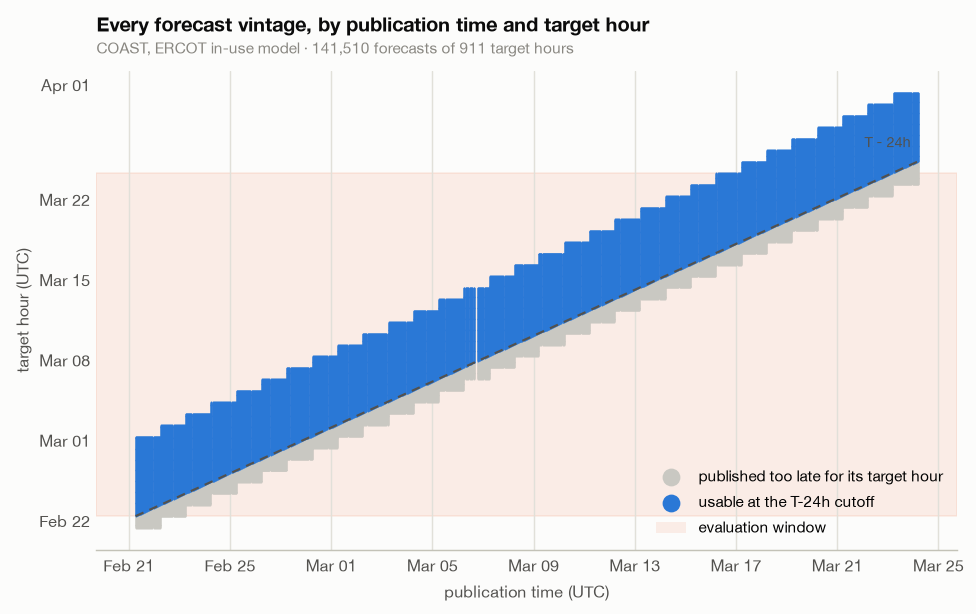

81.0% of published forecasts were eligible for their target hour


In [4]:
landscape = con.execute(
    '''
    SELECT publication_ts_utc, target_ts_utc,
           publication_ts_utc <= target_ts_utc - INTERVAL 24 HOUR AS eligible
    FROM forecast_vintage
    WHERE weather_zone = 'COAST' AND is_ercot_model_in_use
    '''
).df()

fig, ax = plt.subplots(figsize=(7.6, 4.8))
for eligible, color, label, z in (
    (False, viz.CONTEXT, "published too late for its target hour", 1),
    (True, viz.SERIES_ACTUAL, "usable at the T-24h cutoff", 2),
):
    subset = landscape[landscape.eligible == eligible]
    ax.scatter(subset.publication_ts_utc, subset.target_ts_utc, s=1.2, c=color,
               label=label, zorder=z, linewidths=0)

low, high = landscape.publication_ts_utc.min(), landscape.publication_ts_utc.max()
ax.plot([low, high], [low + dt.timedelta(hours=24), high + dt.timedelta(hours=24)],
        color=viz.INK_SECONDARY, lw=1.2, ls=(0, (4, 3)), zorder=3)
ax.annotate("T - 24h", xy=(high, high + dt.timedelta(hours=24)), xytext=(-4, 8),
            textcoords="offset points", ha="right", fontsize=8, color=viz.INK_SECONDARY)
ax.axhspan(context.window_start_utc, context.window_end_utc,
           color=viz.SERIES_ERCOT, alpha=0.10, zorder=0)
viz.frame(ax, x_grid=True)
viz.title(ax, "Every forecast vintage, by publication time and target hour",
          f"COAST, ERCOT in-use model · {len(landscape):,} forecasts of "
          f"{landscape.target_ts_utc.nunique()} target hours")
from matplotlib.patches import Patch

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor=viz.SERIES_ERCOT, alpha=0.10, label="evaluation window"))
ax.legend(handles=handles, loc="lower right", markerscale=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.yaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_xlabel("publication time (UTC)")
ax.set_ylabel("target hour (UTC)")
fig.tight_layout()
plt.show()

print(f"{landscape.eligible.mean():.1%} of published forecasts were eligible for their target hour")

<a id="part-1"></a>
# Part 1 · The as-of join

> **Asked** — one SQL query producing one row per weather zone and target hour,
> carrying the forecast vintage actually available at the 24-hour cutoff, the
> reported actual, and the error with a stated sign convention. *Do not
> substitute a later vintage simply because it is now available.*
>
> **Decided** — [`sql/asof_join.sql`](../sql/asof_join.sql), one query, run
> unmodified by the pipeline. Sign convention: **`error = forecast − actual`**,
> so a positive error is an over-forecast.
>
> **Traded** — it is a long query with four CTEs rather than four small ones.
> Splitting it would read better and would let a later stage silently
> re-select on a different clock. One query means one place the cutoff lives.

### The three clocks

The single most common way this goes quietly wrong is collapsing the cutoff to
one global "as of yesterday" timestamp. It is **per target hour**: the forecast
for 03:00 and the forecast for 22:00 have different deadlines.

| Selected | Clock | Predicate |
|---|---|---|
| ERCOT forecast | decision time | `publication_ts ≤ target_ts − 24h` |
| Seasonal-naive input | decision time | `publication_ts ≤ target_ts − 24h` |
| Reported actual | evaluation time | `publication_ts ≤ processing_ts` |

The actual is *truth*, not an input. It is allowed to arrive after the target
hour — that is the whole point of evaluating later. The naive input is a
*model input*, so it must clear the same 24-hour bar as the forecast. Getting
that distinction backwards is the leakage an interviewer will probe for.

### The three memo questions, answered here

> **No publication exactly at `T − 24h`?** Take the latest publication at or
> before it. A day-ahead process runs with whatever the newest file is when the
> deadline passes; it does not wait for one to land exactly on the second. The
> gate separately flags when that "newest" is suspiciously old — see
> `STALE_FORECAST_VINTAGE` in [Part 3](#part-3).
>
> **Spring-forward and fall-back?** Never by hour arithmetic. `time.resolve_hour`
> maps `(operating_date, hour_ending, dst_flag)` to an unambiguous UTC instant,
> and `DSTFlag` is read as what it is — a discriminator for the *repeated* hour
> at fall-back, not a boolean for "is daylight time". Section 1.4 below.
>
> **Same publication timestamp, two different values?** Neither is kept. The row
> is emitted with `value_count > 1` and the readiness gate refuses the release
> (`CONFLICTING_ASOF_FORECAST`). There is no evidence saying which is
> authoritative, so inventing a tie-break — last wins, max, source order —
> would be manufacturing a fact. Quarantine, don't resolve.

### 1.1 What the selection actually picks

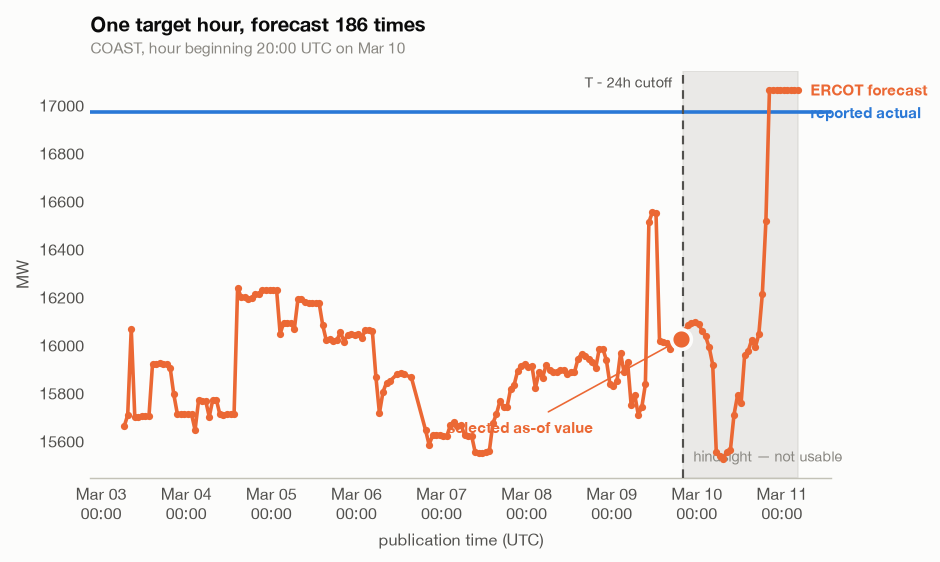

as-of forecast 16,018 MW  ·  actual 16,964 MW  ·  error -946 MW
best forecast ever published for this hour: 17,059 MW


In [5]:
peak_hour = con.execute(
    '''
    SELECT target_ts_utc, actual_mw, ercot_forecast_mw, ercot_publication_ts_utc, cutoff_ts_utc
    FROM evaluation_dataset
    WHERE weather_zone = 'COAST'
    ORDER BY actual_mw DESC
    LIMIT 1
    '''
).fetchone()
target_ts, actual_mw, asof_mw, asof_publication, cutoff_ts = peak_hour

fan = con.execute(
    '''
    SELECT publication_ts_utc, forecast_mw
    FROM forecast_vintage
    WHERE weather_zone = 'COAST' AND is_ercot_model_in_use AND target_ts_utc = ?
    ORDER BY publication_ts_utc
    ''',
    [target_ts],
).df()

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.axvspan(cutoff_ts, fan.publication_ts_utc.max(), color=viz.CONTEXT, alpha=0.35, zorder=0)
ax.annotate("hindsight — not usable", xy=(cutoff_ts, 0.04), xytext=(6, 0),
            xycoords=("data", "axes fraction"), textcoords="offset points",
            fontsize=8, color=viz.INK_MUTED)

ax.plot(fan.publication_ts_utc, fan.forecast_mw, color=viz.SERIES_ERCOT,
        marker="o", ms=3, zorder=3)
ax.axhline(actual_mw, color=viz.SERIES_ACTUAL, lw=2, zorder=2)
ax.axvline(cutoff_ts, color=viz.INK_SECONDARY, lw=1.2, ls=(0, (4, 3)), zorder=4)
ax.annotate("T - 24h cutoff", xy=(cutoff_ts, 0.96), xytext=(-6, 0),
            xycoords=("data", "axes fraction"), textcoords="offset points",
            ha="right", fontsize=8, color=viz.INK_SECONDARY)

ax.scatter([asof_publication], [asof_mw], s=120, facecolor=viz.SERIES_ERCOT,
           edgecolor=viz.SURFACE, linewidths=2, zorder=5)
ax.annotate("selected as-of value", xy=(asof_publication, asof_mw), xytext=(0.58, 0.11),
            textcoords="axes fraction", ha="center", fontsize=8.5,
            weight="bold", color=viz.SERIES_ERCOT,
            arrowprops={"arrowstyle": "-", "color": viz.SERIES_ERCOT,
                        "linewidth": 0.9, "shrinkB": 9, "shrinkA": 3})

viz.frame(ax)
viz.title(ax, f"One target hour, forecast {len(fan)} times",
          f"COAST, hour beginning {target_ts:%H:%M} UTC on {target_ts:%b %d}")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
ax.set_ylabel("MW")
ax.set_xlabel("publication time (UTC)")
fig.tight_layout(rect=(0, 0, 0.87, 1))
viz.endpoint_labels(ax, [
    (fan.publication_ts_utc.max(), actual_mw, "reported actual", viz.SERIES_ACTUAL),
    (fan.publication_ts_utc.max(), fan.forecast_mw.iloc[-1], "ERCOT forecast", viz.SERIES_ERCOT),
])
plt.show()

print(f"as-of forecast {asof_mw:,.0f} MW  ·  actual {actual_mw:,.0f} MW  "
      f"·  error {asof_mw - actual_mw:+,.0f} MW")
print(f"best forecast ever published for this hour: "
      f"{fan.forecast_mw.iloc[(fan.forecast_mw - actual_mw).abs().argmin()]:,.0f} MW")

### 1.2 What hindsight is worth

Change one predicate — take the *latest* vintage per target hour instead of the
latest publishable by the cutoff — and rerun the same evaluation on the same
data.

Nothing errors. No row goes missing. Every chart still renders. The model
simply looks considerably better than it was. **This is the failure mode the
whole pipeline exists to prevent: not a crash, a plausible number.**

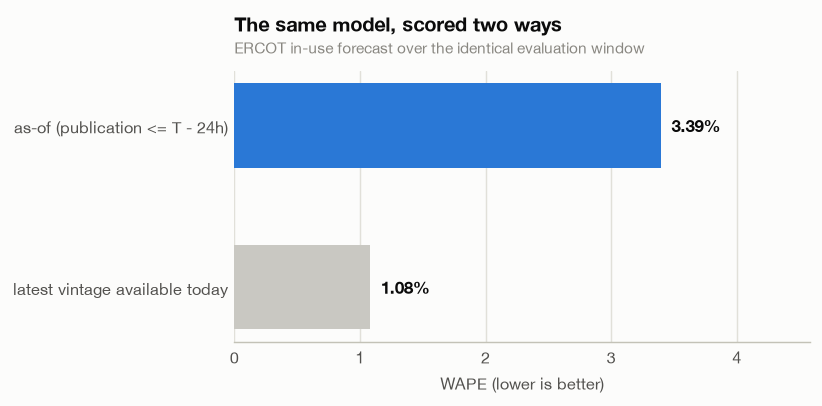

                selection rule   WAPE %
as-of (publication <= T - 24h) 3.393781
latest vintage available today 1.080350

Hindsight would report the model 3.1x better than it was at decision time.
The seasonal-naive model is unaffected by this particular trap: its input is an actual
from seven days earlier, published six days before the cutoff, and NP6-345 was never
observed to revise. A model being immune to one leak is not evidence the pipeline is safe.


In [6]:
hindsight_wape = con.execute(
    '''
    WITH latest AS (
        SELECT weather_zone, target_ts_utc, forecast_mw,
               row_number() OVER (PARTITION BY weather_zone, target_ts_utc
                                  ORDER BY publication_ts_utc DESC) AS rn
        FROM forecast_vintage
        WHERE is_ercot_model_in_use AND weather_zone <> 'SYSTEM_TOTAL'
    )
    SELECT 100 * sum(abs(l.forecast_mw - e.actual_mw)) / sum(e.actual_mw)
    FROM evaluation_dataset e
    JOIN latest l USING (weather_zone, target_ts_utc)
    WHERE l.rn = 1
    '''
).fetchone()[0]

comparison = pd.DataFrame(
    {
        "selection rule": ["as-of (publication <= T - 24h)", "latest vintage available today"],
        "WAPE %": [ercot_model.wape_pct, hindsight_wape],
    }
)

fig, ax = plt.subplots(figsize=(6.4, 3.2))
bars = ax.barh(comparison["selection rule"], comparison["WAPE %"],
               height=0.52, color=[viz.SERIES_ACTUAL, viz.CONTEXT], zorder=2)
for bar, value in zip(bars, comparison["WAPE %"]):
    ax.annotate(f"{value:.2f}%", xy=(value, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9.5, weight="bold", color=viz.INK)
viz.frame(ax)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.invert_yaxis()
ax.set_xlim(0, max(comparison["WAPE %"]) * 1.35)
viz.title(ax, "The same model, scored two ways",
          "ERCOT in-use forecast over the identical evaluation window")
ax.set_xlabel("WAPE (lower is better)")
fig.tight_layout()
plt.show()

print(comparison.to_string(index=False))
print(f"\nHindsight would report the model {ercot_model.wape_pct / hindsight_wape:.1f}x better "
      f"than it was at decision time.")
print("The seasonal-naive model is unaffected by this particular trap: its input is an actual\n"
      "from seven days earlier, published six days before the cutoff, and NP6-345 was never\n"
      "observed to revise. A model being immune to one leak is not evidence the pipeline is safe.")

### 1.3 Why 24 hours costs what it costs

The gap between those two numbers is the accuracy ERCOT gains in the final day
before an hour arrives. Scoring every vintage by publication lead time makes
the trade explicit.

Note the region left of zero: ERCOT's seven-day file published at 05:30 also
restates hours *earlier that same day*, which have already happened. Those rows
are published after the fact, and they are exactly what a "latest vintage" rule
silently reaches for.

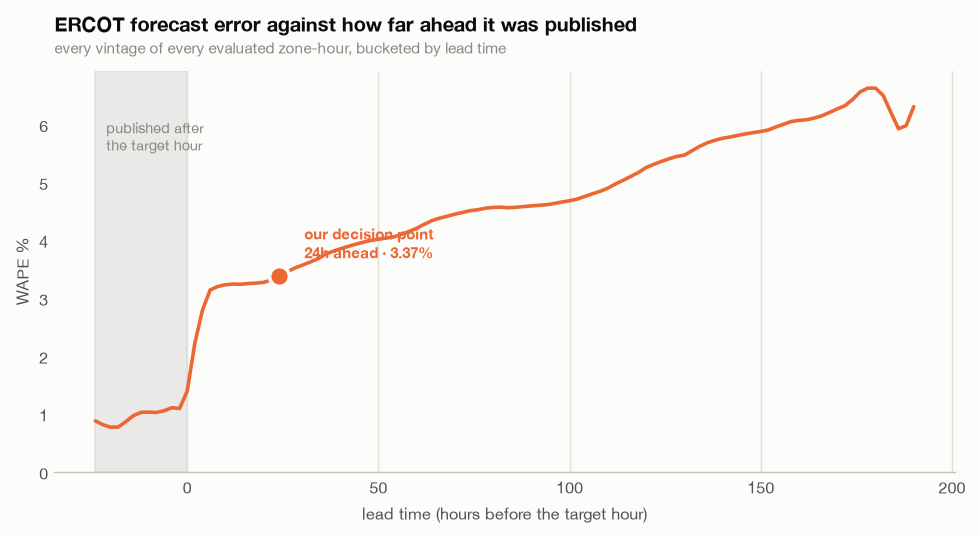

 lead_hours  wape  observations
          0  1.39         11424
          6  3.14         11424
         12  3.24         11424
         24  3.37         11416
         48  3.99         11032
         96  4.63         10264
        144  5.81          9496


In [7]:
lead = con.execute(
    '''
    SELECT CAST(date_diff('minute', f.publication_ts_utc, f.target_ts_utc) / 60 AS INTEGER) AS lead_hours,
           100 * sum(abs(f.forecast_mw - e.actual_mw)) / sum(e.actual_mw) AS wape,
           count(*) AS observations
    FROM forecast_vintage f
    JOIN evaluation_dataset e USING (weather_zone, target_ts_utc)
    WHERE f.is_ercot_model_in_use
    GROUP BY 1
    HAVING count(*) >= 200
    ORDER BY 1
    '''
).df()

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.axvspan(lead.lead_hours.min(), 0, color=viz.CONTEXT, alpha=0.35, zorder=0)
ax.annotate("published after\nthe target hour", xy=(lead.lead_hours.min(), 0.88),
            xytext=(6, 0), xycoords=("data", "axes fraction"),
            textcoords="offset points", fontsize=8, color=viz.INK_MUTED, va="top")
ax.plot(lead.lead_hours, lead.wape, color=viz.SERIES_ERCOT, zorder=3)

decision = lead.loc[(lead.lead_hours - 24).abs().idxmin()]
ax.scatter([decision.lead_hours], [decision.wape], s=120, facecolor=viz.SERIES_ERCOT,
           edgecolor=viz.SURFACE, linewidths=2, zorder=4)
ax.annotate(f"our decision point\n24h ahead · {decision.wape:.2f}%",
            xy=(decision.lead_hours, decision.wape), xytext=(14, 10),
            textcoords="offset points", fontsize=8.5, color=viz.SERIES_ERCOT, weight="bold")

viz.frame(ax, x_grid=True)
viz.title(ax, "ERCOT forecast error against how far ahead it was published",
          "every vintage of every evaluated zone-hour, bucketed by lead time")
ax.set_xlabel("lead time (hours before the target hour)")
ax.set_ylabel("WAPE %")
ax.set_ylim(0, None)
fig.tight_layout()
plt.show()

print(lead[lead.lead_hours.isin([0, 6, 12, 24, 48, 96, 144])]
      .assign(wape=lambda d: d.wape.round(2)).to_string(index=False))

### 1.4 A local operating day is not 24 hours

Coverage checks that hard-code 24 are wrong twice a year. The readiness gate
derives the expected count from the calendar, so a DST day is not reported as
missing data — and a DST day that *does* have 24 rows is.

The same reasoning drives the seasonal-naive lag: seven calendar days at the
same local hour is 167 or 169 hours across a transition, so the join is on
`(operating_date − 7, hour_ending, dst_flag)` rather than on arithmetic.

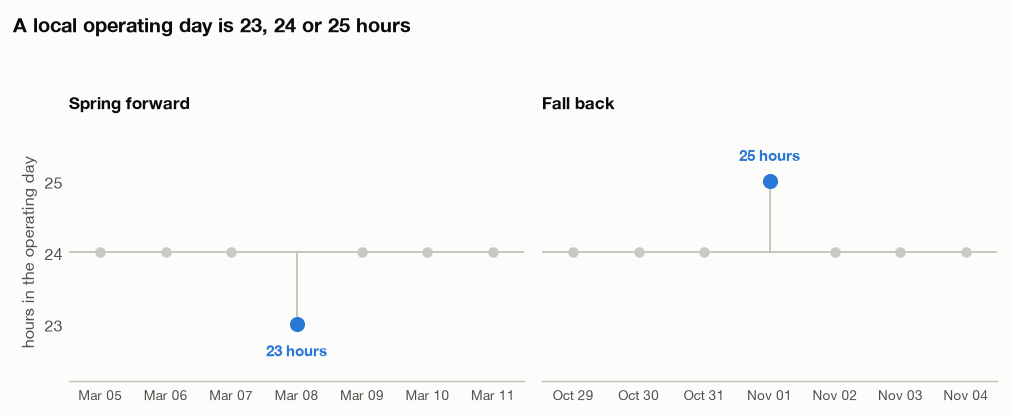

transition  Fall back  Spring forward
day                                  
2026-03-05        NaN            24.0
2026-03-06        NaN            24.0
2026-03-07        NaN            24.0
2026-03-08        NaN            23.0
2026-03-09        NaN            24.0
2026-03-10        NaN            24.0
2026-03-11        NaN            24.0
2026-10-29       24.0             NaN
2026-10-30       24.0             NaN
2026-10-31       24.0             NaN
2026-11-01       25.0             NaN
2026-11-02       24.0             NaN
2026-11-03       24.0             NaN
2026-11-04       24.0             NaN

expected evaluation rows for this window: observed 5752


In [8]:
def transition_week(centre: dt.date) -> pd.DataFrame:
    days = [centre + dt.timedelta(days=offset) for offset in range(-3, 4)]
    return pd.DataFrame({"day": days, "hours": [hours_in_operating_date(d) for d in days]})

weeks = [("Spring forward", transition_week(dt.date(2026, 3, 8))),
         ("Fall back", transition_week(dt.date(2026, 11, 1)))]

# A dot plot, not bars: 23 against 24 is a one-part-in-24 difference that a
# zero-baselined bar cannot show, and truncating a bar axis would misencode
# length. Dots encode position, so a tight axis is honest here.
fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.2), sharey=True)
for ax, (label, week) in zip(axes, weeks):
    ax.axhline(24, color=viz.BASELINE, lw=1, zorder=1)
    for position, hours in enumerate(week.hours):
        odd = hours != 24
        ax.plot([position, position], [24, hours], color=viz.BASELINE, lw=1, zorder=1)
        ax.scatter([position], [hours], s=70 if odd else 34,
                   c=viz.SERIES_ACTUAL if odd else viz.CONTEXT, zorder=3, linewidths=0)
        if odd:
            ax.annotate(f"{hours} hours", xy=(position, hours),
                        xytext=(0, 11 if hours > 24 else -18), textcoords="offset points",
                        ha="center", fontsize=8.5, weight="bold", color=viz.SERIES_ACTUAL)
    viz.frame(ax)
    ax.grid(axis="y", visible=False)
    ax.set_title(label, fontsize=9.5, color=viz.INK, loc="left", pad=8, weight="bold")
    ax.set_xticks(range(len(week)), [d.strftime("%b %d") for d in week.day], fontsize=7.5)
    ax.set_ylim(22.2, 25.8)
    ax.set_yticks([23, 24, 25])
    ax.margins(x=0.08)
axes[0].set_ylabel("hours in the operating day")
fig.suptitle("A local operating day is 23, 24 or 25 hours",
             fontsize=11, color=viz.INK, x=0.012, ha="left", weight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

print(pd.concat([week.assign(transition=label) for label, week in weeks])
      .pivot(index="day", columns="transition", values="hours")
      .to_string())
print("")
print(f"expected evaluation rows for this window: "
      f"observed {readiness.metrics['evaluation_rows']}")

### 1.5 The DST finding that has real consequences

Spring-forward does not just shorten a day. It puts a **hole in the
seasonal-naive model exactly one week later**, and the pipeline finds it
without being told to look.

In [9]:
missing_naive = con.execute(
    """
    SELECT operating_date, hour_ending, dst_flag, count(*) AS zone_hours
    FROM evaluation_dataset
    WHERE naive_forecast_mw IS NULL
    GROUP BY 1, 2, 3 ORDER BY 1, 2
    """
).df()

hours_0308 = con.execute(
    """
    SELECT DISTINCT hour_ending FROM actual_vintage
    WHERE operating_date = DATE '2026-03-08' ORDER BY 1
    """
).df().hour_ending.tolist()

print(f"2026-03-08 is a {hours_in_operating_date(dt.date(2026, 3, 8))}-hour operating day.")
print(f"  hours ERCOT reports: {hours_0308}")
print(f"  absent: hour ending {sorted(set(range(1, 25)) - set(hours_0308))}  "
      "-- the 02:00-03:00 hour the clocks skip\n")
print("Seven days later, 2026-03-15 has a full 24 hours. Its hour ending 3 therefore")
print("asks for a seasonal-naive input that never existed:\n")
print(missing_naive.to_string(index=False))
print()
print("The pipeline does not impute it, borrow the neighbouring hour, or silently")
print("drop the row. It emits the row with a NULL input and lets the readiness gate")
print("account for it (MISSING_NAIVE_INPUT). A model that quietly fills this hole")
print("would be inventing a week-over-week comparison that has no left-hand side.")

2026-03-08 is a 23-hour operating day.
  hours ERCOT reports: [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
  absent: hour ending [3]  -- the 02:00-03:00 hour the clocks skip

Seven days later, 2026-03-15 has a full 24 hours. Its hour ending 3 therefore
asks for a seasonal-naive input that never existed:

operating_date  hour_ending dst_flag  zone_hours
    2026-03-15            3        N           8

The pipeline does not impute it, borrow the neighbouring hour, or silently
drop the row. It emits the row with a NULL input and lets the readiness gate
account for it (MISSING_NAIVE_INPUT). A model that quietly fills this hole
would be inventing a week-over-week comparison that has no left-hand side.


<a id="part-2"></a>
# Part 2 · The batch pipeline

> **Asked** — one documented command for a processing date; identical inputs
> rerun produce the same final state; **no silent row loss** — every input row
> accounted for, including anything not admitted; evidence in automation.
>
> **Decided** — DuckDB, single file, four tables. `source_row` is a ledger: one
> row in a source CSV produces exactly one ledger row, carrying its raw line and
> a disposition. Determinism comes from `processing_ts`, a visibility cutoff
> that hides anything published after the processing date no matter what the
> archive holds when the run actually executes.
>
> **Traded** — DuckDB over Postgres or Parquet-on-disk. It is a single
> gitignorable file a reviewer can rebuild in under a minute, and the as-of
> query is plain SQL. It is not a multi-writer store, which a real deployment
> would need.
>
> **Open** — the ledger has **zero quarantined rows** across the real window.
> Every real dispositon is `ACCEPTED`. The quarantine paths are exercised by
> fixtures and tests only. That is honest but weaker evidence than a naturally
> occurring bad row would be, and it is stated rather than glossed.

### One command

```bash
forecast-spine run --processing-date 2026-03-24 \
                   --window-start 2026-02-22 --window-end 2026-03-23
```

### 2.1 Row accountability — where every input row went

In [10]:
ledger = con.execute(
    """
    SELECT report_key, disposition, count(*) AS rows
    FROM source_row GROUP BY 1, 2 ORDER BY 1, 3 DESC
    """
).df()

raw_rows = con.execute("SELECT sum(raw_row_count) FROM source_file").fetchone()[0]
ledger_rows = con.execute("SELECT count(*) FROM source_row").fetchone()[0]

print(ledger.to_string(index=False))
print()
print(f"raw data lines across all source files : {raw_rows:,}")
print(f"rows in the ledger                     : {ledger_rows:,}")
print(f"unaccounted                            : {raw_rows - ledger_rows:,}")
print()
print("The readiness gate re-derives this independently and fails with")
print("SOURCE_ROWS_UNACCOUNTED if the two disagree by even one row. It does not")
print("trust the loader's own count.")
print()
print("Dispositions the ledger can carry (normalize.py):")
known = ["ACCEPTED", "DUPLICATE_IDENTICAL", *sorted(normalize.QUARANTINE_DISPOSITIONS)]
for disposition in known:
    seen = "  <- present in this run" if disposition in set(ledger.disposition) else ""
    print(f"  {disposition:28s}{seen}")
print()
print("Only ACCEPTED occurs in this window. The quarantine branches are covered by")
print("`forecast-spine demo` (conflicting_duplicate, schema_drift, missing_forecast)")
print("and by tests/test_accounting.py -- not by naturally occurring bad rows.")

   report_key disposition    rows
  actual_load    ACCEPTED     887
load_forecast    ACCEPTED 1132080

raw data lines across all source files : 1,132,967
rows in the ledger                     : 1,132,967
unaccounted                            : 0

The readiness gate re-derives this independently and fails with
SOURCE_ROWS_UNACCOUNTED if the two disagree by even one row. It does not
trust the loader's own count.

Dispositions the ledger can carry (normalize.py):
  ACCEPTED                      <- present in this run
  DUPLICATE_IDENTICAL         
  QUARANTINED_INVALID_VALUE   
  QUARANTINED_KEY_CONFLICT    
  QUARANTINED_PARSE_ERROR     
  QUARANTINED_SCHEMA_ERROR    

Only ACCEPTED occurs in this window. The quarantine branches are covered by
`forecast-spine demo` (conflicting_duplicate, schema_drift, missing_forecast)
and by tests/test_accounting.py -- not by naturally occurring bad rows.


### 2.2 Rerun safety

`run_id` is `sha256(pipeline_version + processing_date + sorted content hashes
of every admitted source file)`. Rebuilding the context from the same directory
must produce the same id; if a vintage were added, removed or altered, it must
not.

In [11]:
again = pipeline.build_context(
    context.processing_date, raw_root,
    window_start=WINDOW_START, window_end=WINDOW_END,
) if LIVE else pipeline.build_context(context.processing_date, raw_root, window_days=1)

print(f"run_id, first build   {context.run_id}")
print(f"run_id, rebuilt       {again.run_id}")
print(f"identical             {context.run_id == again.run_id}")
print()

# Determinism has two halves. The digest must be stable for the same inputs,
# and it must move when the visible input set moves.
if LIVE:
    earlier = pipeline.build_context(
        dt.date(2026, 3, 10), raw_root, window_start=WINDOW_START, window_end=dt.date(2026, 3, 9),
    )
    print("An earlier processing date sees strictly fewer vintages:")
    print(f"  files visible at {context.processing_date}: {len(context.source_files):,}")
    print(f"  files visible at {earlier.processing_date}: {len(earlier.source_files):,}")
    print(f"  run_id differs: {context.run_id != earlier.run_id}")
    print()

print("The converse matters more, and is the property tests/test_rerun.py pins:")
print("rerunning 2026-03-24 *after* later vintages have landed still produces this")
print("same run_id and the same answer, because processing_ts hides anything")
print("published after the processing date. A rerun is reproducible, not merely")
print("repeatable -- the archive growing underneath it changes nothing.")

run_id, first build   ae80e7096413957c6de9fafe9058c20b
run_id, rebuilt       ae80e7096413957c6de9fafe9058c20b
identical             True

An earlier processing date sees strictly fewer vintages:
  files visible at 2026-03-24: 775
  files visible at 2026-03-10: 449
  run_id differs: True

The converse matters more, and is the property tests/test_rerun.py pins:
rerunning 2026-03-24 *after* later vintages have landed still produces this
same run_id and the same answer, because processing_ts hides anything
published after the processing date. A rerun is reproducible, not merely
repeatable -- the archive growing underneath it changes nothing.


<a id="part-3"></a>
# Part 3 · The eval gates

> **Asked** — two separate executable pass/fail stages, structured actionable
> reasons, both exercised by automation, both outcomes demonstrably reachable.
> Plus: *explain one concrete way a bad forecast could still pass the model
> gate.*
>
> **Decided** — `data_readiness` decides whether the **run** is fit to release;
> `seasonal_naive_gate` decides whether the **model** is fit to ship. Readiness
> runs first and a failure blocks the model gate entirely — scoring a dataset
> you have just declared untrustworthy produces a number that means nothing.
>
> **Traded** — a strict readiness gate makes the pipeline brittle: three
> failures below are things a laxer gate would have waved through. The
> alternative is a gate that never stops anything, which is decoration. The
> split chosen is: **FAIL when the evaluation would be incorrect or ambiguous;
> nothing is a warning that would change the number.**
>
> **Open** — the thresholds were calibrated on the September window. Section 3.6
> is what happened when they met March.

### Why the readiness gate re-derives instead of trusting

The gate deliberately does not trust `sql/asof_join.sql`. It re-checks the
cutoff predicate with its own independent query, so a change to the join that
admitted future data would have to be made identically in two places to go
unnoticed. `tests/test_gates.py::test_readiness_gate_does_not_trust_the_query_it_gates`
is what holds that line.

### 3.1 The readiness verdict on the assignment window

In [12]:
def show(result) -> None:
    print(f"[{result.status}] {result.gate}")
    for reason in result.reasons:
        print(f"  {reason.code} (count={reason.count})")
        print("   ", textwrap.fill(reason.detail, 92, subsequent_indent="    "))
        for sample in reason.sample_keys[:3]:
            print(f"      e.g. {sample}")
    if not result.reasons:
        print("  no reasons -- every check passed")

show(readiness)

[FAIL] data_readiness
  MISSING_ASOF_FORECAST (count=8)
    8 target zone-hours where no ERCOT forecast was publishable by the cutoff; these are never
    back-filled from a later vintage
      e.g. COAST 2026-02-22T06:00Z
      e.g. EAST 2026-02-22T06:00Z
      e.g. FAR_WEST 2026-02-22T06:00Z
  MISSING_NAIVE_INPUT (count=8)
    8 target zone-hours where no seasonal-naive input was publishable by the cutoff; these are
    never back-filled from a later vintage
      e.g. COAST 2026-03-15T07:00Z
      e.g. EAST 2026-03-15T07:00Z
      e.g. FAR_WEST 2026-03-15T07:00Z
  STALE_FORECAST_VINTAGE (count=16)
    16 target zone-hours whose newest publishable forecast was up to 3.5h old at its cutoff
    (limit 2.0h). NP3-565 publishes hourly, so this indicates missed acquisition rather than
    a late ERCOT publication
      e.g. COAST 2026-03-07T19:00Z 3.5
      e.g. EAST 2026-03-07T19:00Z 3.5
      e.g. FAR_WEST 2026-03-07T19:00Z 3.5


**Three failures, three different kinds of thing.** Reading them in order is the
whole argument of this submission.

| Code | Rows | What it is | Is it a defect? |
|---|---|---|---|
| `MISSING_ASOF_FORECAST` | 8 | 2026-02-22 HE 1 | **No — structural.** Its cutoff is 2026-02-21 00:00. Publications post at HH:30, so the earliest the assignment's own publication window permits is 00:30, thirty minutes too late. No process could have served this hour from the stated window. |
| `MISSING_NAIVE_INPUT` | 8 | 2026-03-15 HE 3 | **No — the calendar.** Its seasonal-naive input is 2026-03-08 HE 3, an hour spring-forward deletes. See [1.5](#part-1). |
| `STALE_FORECAST_VINTAGE` | 16 | 2026-03-07 HE 13–14 | **Yes — a real data gap.** ERCOT's archive is missing five publications on 2026-03-06, so the newest vintage publishable by these hours' cutoffs was 2.5h and 3.5h old against a 2h limit. |

The first two are reported rather than fixed. Reaching back to a 20 February
vintage would serve 2026-02-22 HE 1 and would also break the publication window
the assignment specifies; imputing the naive input for 2026-03-15 HE 3 would
invent a week-over-week comparison with no left-hand side. **Neither is worth a
green run.**

The third is the interesting one: a *retrieval* problem that only became a
*data* problem one day later, and only for two hours. That is precisely the
distinction a raw file count cannot make, and why the gate reports per
zone-hour rather than per file.

### 3.2 The dataset being scored

With the selection settled, this is what is actually judged: the reported
actual, ERCOT's own as-of forecast, and the weekly seasonal-naive forecast.

ERCOT's model is shown for context, not as a competitor — the exercise asks for
one model and forbids comparing two. It is here because its vintages are the
material the point-in-time machinery is built on, and because it sets a useful
floor on what this window was capable of.

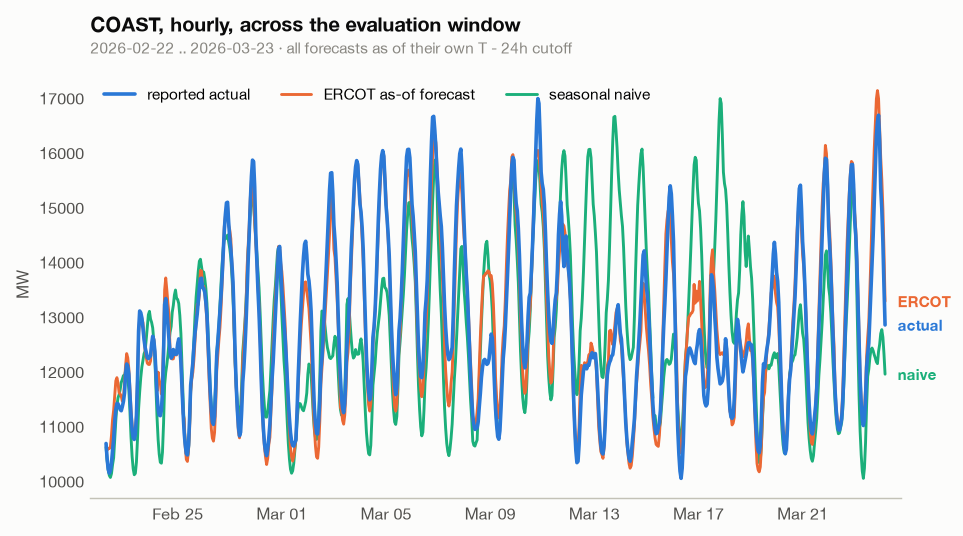

         model  WAPE %  worst day %  worst peak-hour APE %
seasonal naive    8.65        15.08                  32.15
  ERCOT in-use    3.39         5.94                  26.29


In [13]:
series = con.execute(
    '''
    SELECT target_ts_utc, actual_mw, ercot_forecast_mw, naive_forecast_mw
    FROM evaluation_dataset
    WHERE weather_zone = 'COAST'
    ORDER BY target_ts_utc
    '''
).df()

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.plot(series.target_ts_utc, series.actual_mw, color=viz.SERIES_ACTUAL,
        label="reported actual", zorder=4)
ax.plot(series.target_ts_utc, series.ercot_forecast_mw, color=viz.SERIES_ERCOT,
        lw=1.6, label="ERCOT as-of forecast", zorder=3)
ax.plot(series.target_ts_utc, series.naive_forecast_mw, color=viz.SERIES_NAIVE,
        lw=1.6, label="seasonal naive", zorder=2)

viz.frame(ax)
viz.title(ax, "COAST, hourly, across the evaluation window",
          f"{first_day} .. {last_day} · all forecasts as of their own T - 24h cutoff")
ax.legend(loc="upper left", ncols=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_ylabel("MW")
ax.margins(x=0.02)
fig.tight_layout(rect=(0, 0, 0.91, 1))

last = series.iloc[-1]
viz.endpoint_labels(ax, [
    (last.target_ts_utc, last.actual_mw, "actual", viz.SERIES_ACTUAL),
    (last.target_ts_utc, last.ercot_forecast_mw, "ERCOT", viz.SERIES_ERCOT),
    (last.target_ts_utc, last.naive_forecast_mw, "naive", viz.SERIES_NAIVE),
])
plt.show()

print(pd.DataFrame({
    "model": ["seasonal naive", "ERCOT in-use"],
    "WAPE %": [round(naive.wape_pct, 2), round(ercot_model.wape_pct, 2)],
    "worst day %": [round(naive.worst_fold_wape_pct, 2), round(ercot_model.worst_fold_wape_pct, 2)],
    "worst peak-hour APE %": [round(naive.max_peak_hour_ape_pct, 2),
                              round(ercot_model.max_peak_hour_ape_pct, 2)],
}).to_string(index=False))

### 3.3 Where the error lives

A single WAPE hides structure. Broken out by weather zone and hour of the local
operating day, seasonal-naive error is clearly not uniform — it concentrates in
particular zones and particular hours, which a threshold on the pooled number
cannot see.

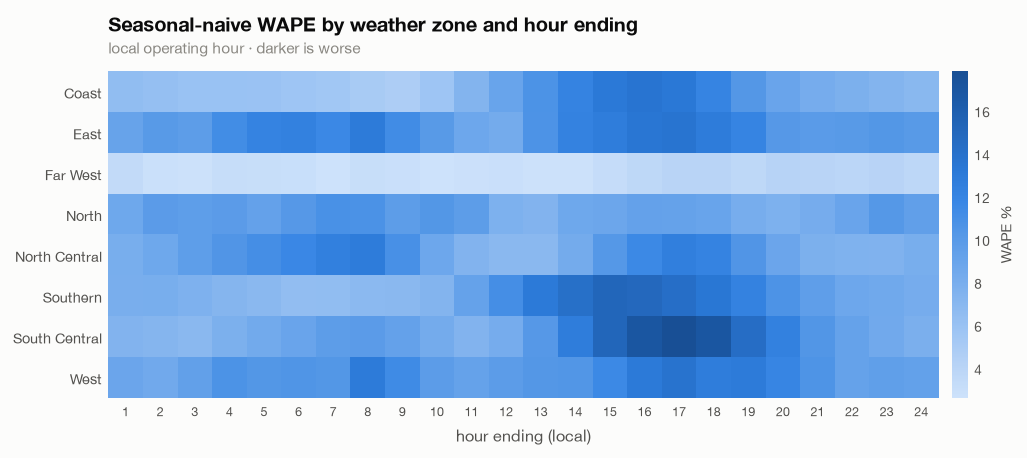

worst zone-hours (WAPE %):
weather_zone   hour_ending
SOUTH_CENTRAL  17             17.84
               16             17.00
               18             16.90
SOUTHERN       15             15.15
SOUTH_CENTRAL  15             15.12


In [14]:
heat = (
    con.execute(
        '''
        SELECT weather_zone, hour_ending,
               100 * sum(abs(naive_error_mw)) / sum(actual_mw) AS wape
        FROM evaluation_dataset
        GROUP BY 1, 2
        '''
    )
    .df()
    .pivot(index="weather_zone", columns="hour_ending", values="wape")
    .sort_index()
)

from matplotlib.colors import LinearSegmentedColormap

ramp = LinearSegmentedColormap.from_list("sequential_blue", viz.SEQUENTIAL)

fig, ax = plt.subplots(figsize=(8.0, 3.6))
image = ax.imshow(heat.values, aspect="auto", cmap=ramp, origin="upper")
ax.set_xticks(range(len(heat.columns)), [str(h) for h in heat.columns], fontsize=7)
ax.set_yticks(range(len(heat.index)), [z.replace("_", " ").title() for z in heat.index], fontsize=8)
ax.grid(visible=False)
for side in ("top", "right", "left", "bottom"):
    ax.spines[side].set_visible(False)
viz.title(ax, "Seasonal-naive WAPE by weather zone and hour ending",
          "local operating hour · darker is worse")
ax.set_xlabel("hour ending (local)")
bar = fig.colorbar(image, ax=ax, pad=0.015, fraction=0.03)
bar.set_label("WAPE %", color=viz.INK_SECONDARY, fontsize=8)
bar.outline.set_visible(False)
bar.ax.tick_params(labelsize=7.5, color=viz.INK_MUTED, labelcolor=viz.INK_SECONDARY)
fig.tight_layout()
plt.show()

worst = heat.stack().sort_values(ascending=False).head(5)
print("worst zone-hours (WAPE %):")
print(worst.round(2).to_string())

### 3.4 Rolling origin, never a random split

Every fold's inputs precede its target, so evaluation runs sequentially by
operating day. The gate checks the window average **and** each individual day:
an acceptable mean must not be covering an unacceptable day.

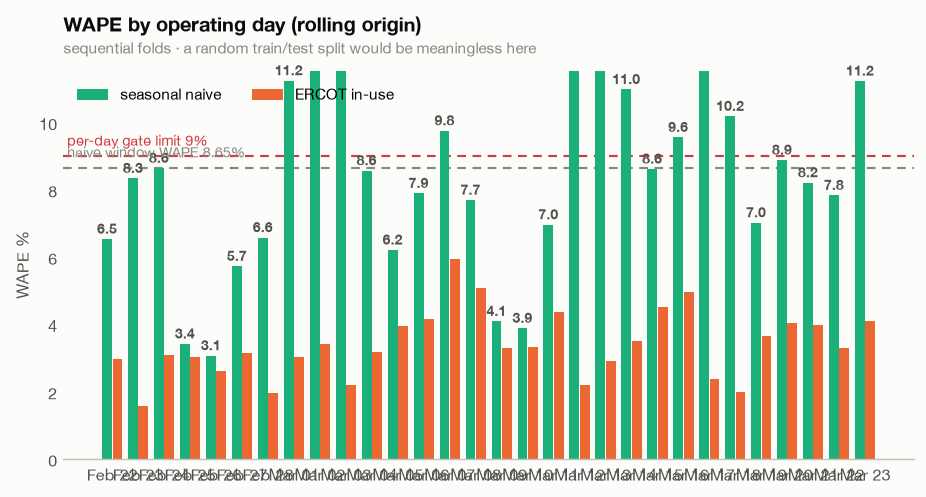

       day  naive  ercot
2026-02-22   6.53   2.98
2026-02-23   8.34   1.56
2026-02-24   8.64   3.10
2026-02-25   3.41   3.03
2026-02-26   3.07   2.62
2026-02-27   5.72   3.14
2026-02-28   6.58   1.94
2026-03-01  11.24   3.03
2026-03-02  12.63   3.40
2026-03-03  13.39   2.20
2026-03-04   8.57   3.19
2026-03-05   6.21   3.96
2026-03-06   7.89   4.17
2026-03-07   9.75   5.94
2026-03-08   7.69   5.07
2026-03-09   4.09   3.29
2026-03-10   3.88   3.33
2026-03-11   6.96   4.37
2026-03-12  14.59   2.20
2026-03-13  13.54   2.91
2026-03-14  10.98   3.50
2026-03-15   8.61   4.50
2026-03-16   9.55   4.95
2026-03-17  15.08   2.37
2026-03-18  10.18   1.97
2026-03-19   7.02   3.65
2026-03-20   8.88   4.02
2026-03-21   8.21   3.99
2026-03-22   7.83   3.28
2026-03-23  11.23   4.09


In [15]:
folds = pd.DataFrame(
    [{"day": f.operating_date, "naive": f.wape_pct} for f in naive.folds]
).merge(
    pd.DataFrame([{"day": f.operating_date, "ercot": f.wape_pct} for f in ercot_model.folds]),
    on="day",
)

thresholds = gates.Thresholds()
positions = range(len(folds))
width = 0.38

fig, ax = plt.subplots(figsize=(7.2, 3.9))
ax.bar([p - width / 2 - 0.01 for p in positions], folds["naive"], width,
       color=viz.SERIES_NAIVE, label="seasonal naive", zorder=2)
ax.bar([p + width / 2 + 0.01 for p in positions], folds["ercot"], width,
       color=viz.SERIES_ERCOT, label="ERCOT in-use", zorder=2)
for position, value in zip(positions, folds["naive"]):
    ax.annotate(f"{value:.1f}", xy=(position - width / 2 - 0.01, value), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=8,
                color=viz.INK_SECONDARY, weight="bold")

viz.threshold(ax, thresholds.max_fold_wape_pct,
              f"per-day gate limit {thresholds.max_fold_wape_pct:.0f}%",
              color=viz.STATUS_CRITICAL, ha="left")
viz.threshold(ax, naive.wape_pct, f"naive window WAPE {naive.wape_pct:.2f}%", ha="left")

viz.frame(ax)
viz.title(ax, "WAPE by operating day (rolling origin)",
          "sequential folds · a random train/test split would be meaningless here")
ax.set_xticks(list(positions), [d.strftime("%b %d") for d in folds["day"]])
ax.set_ylabel("WAPE %")
ax.set_ylim(0, thresholds.max_fold_wape_pct * 1.28)
ax.legend(loc="upper left", ncols=2)
fig.tight_layout()
plt.show()

print(folds.round(2).to_string(index=False))

### 3.5 The guardrail a pooled WAPE cannot provide

> *"Explain one concrete way a bad forecast could still pass the model gate."*

**Here it is.** A model can post a respectable window average and still be badly
wrong exactly where error is expensive. Pooled WAPE is dominated by the large
zones and by the many cheap overnight hours; a forecast that is excellent at
03:00 in a small zone and catastrophic at the summer peak in `NORTH_CENTRAL`
can clear an 8% pooled threshold comfortably.

**What closes it:** a second, independent limit on peak-hour error, checked per
zone-day rather than pooled.
`tests/test_gates.py::test_a_good_average_does_not_excuse_a_bad_peak_hour`
corrupts a single zone-day peak, confirms pooled WAPE still passes, and shows
this guardrail is what refuses the release.

**What it does not close:** a forecast that is uniformly, mildly biased in one
direction. Bias cancels in an absolute-error metric and there is no threshold on
it here. The compensating signal I would monitor is the sign-preserving
`bias_mw` already computed per fold — a run of same-signed daily bias is the
observable symptom, and it is visible in the fold table above without being
gated on.

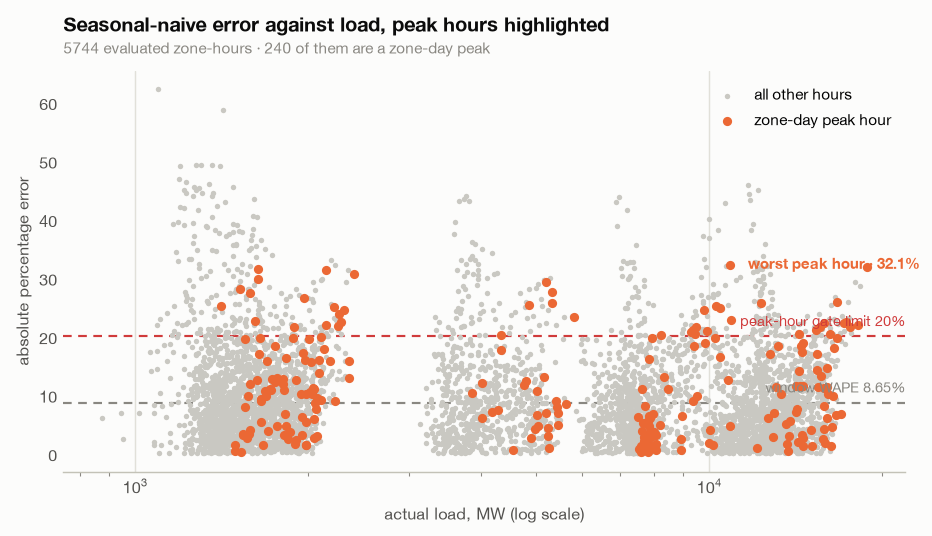

overall WAPE 8.65% passes the 8% limit
worst peak-hour APE 32.15% against a 20% limit — headroom, but not much


In [16]:
points = con.execute(
    '''
    SELECT actual_mw,
           100 * abs(naive_error_mw) / actual_mw AS ape,
           row_number() OVER (PARTITION BY weather_zone, operating_date
                              ORDER BY actual_mw DESC) = 1 AS is_peak
    FROM evaluation_dataset
    WHERE actual_mw > 0 AND naive_forecast_mw IS NOT NULL
    '''
).df()

fig, ax = plt.subplots(figsize=(7.4, 4.2))
ordinary = points[~points.is_peak]
peaks = points[points.is_peak]
ax.scatter(ordinary.actual_mw, ordinary.ape, s=9, c=viz.CONTEXT,
           label="all other hours", linewidths=0, zorder=2)
ax.scatter(peaks.actual_mw, peaks.ape, s=26, c=viz.SERIES_ERCOT,
           label="zone-day peak hour", linewidths=0, zorder=3)

viz.threshold(ax, gates.Thresholds().max_peak_hour_ape_pct,
              f"peak-hour gate limit {gates.Thresholds().max_peak_hour_ape_pct:.0f}%",
              color=viz.STATUS_CRITICAL)
viz.threshold(ax, naive.wape_pct, f"window WAPE {naive.wape_pct:.2f}%")

worst_peak = peaks.loc[peaks.ape.idxmax()]
ax.annotate(f"worst peak hour · {worst_peak.ape:.1f}%",
            xy=(worst_peak.actual_mw, worst_peak.ape), xytext=(10, -2),
            textcoords="offset points", fontsize=8.5, weight="bold", color=viz.SERIES_ERCOT)

viz.frame(ax, x_grid=True)
viz.title(ax, "Seasonal-naive error against load, peak hours highlighted",
          f"{len(points)} evaluated zone-hours · {len(peaks)} of them are a zone-day peak")
ax.set_xscale("log")
ax.set_xlabel("actual load, MW (log scale)")
ax.set_ylabel("absolute percentage error")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

print(f"overall WAPE {naive.wape_pct:.2f}% passes the {gates.Thresholds().max_wape_pct:.0f}% limit")
print(f"worst peak-hour APE {peaks.ape.max():.2f}% against a "
      f"{gates.Thresholds().max_peak_hour_ape_pct:.0f}% limit — headroom, but not much")

### 3.6 The model verdict — and the threshold problem

This is the most important open issue in the submission, so it is stated
plainly rather than tuned away.

In [17]:
show(model_gate)
print()

t = gates.Thresholds()
rows = [
    ("pooled WAPE", naive.wape_pct, t.max_wape_pct),
    ("worst single day (fold WAPE)", naive.worst_fold_wape_pct, t.max_fold_wape_pct),
    ("worst zone-day peak-hour APE", naive.max_peak_hour_ape_pct, t.max_peak_hour_ape_pct),
]
print(f"{'measure':32s} {'observed':>10s} {'limit':>8s}   verdict")
for label, observed, limit in rows:
    print(f"{label:32s} {observed:9.2f}% {limit:7.1f}%   "
          f"{'PASS' if observed <= limit else 'FAIL'}")
print()
print(f"ERCOT's own model over the same rows: {ercot_model.wape_pct:.2f}% WAPE")
print(f"seasonal-naive bias: {naive.bias_mw:+,.0f} MW    p95 APE: {naive.p95_ape_pct:.1f}%")

[FAIL] seasonal_naive
  INCOMPLETE_SCORING (count=8)
    scored 5744 of 5752 evaluation rows; the metric does not cover the dataset it reports on
  WAPE_ABOVE_THRESHOLD (count=1)
    WAPE 8.65% exceeds 8.00%
  FOLD_WAPE_ABOVE_THRESHOLD (count=11)
    11 operating days exceed 9.00% WAPE; an acceptable window average is hiding an unacceptable
    day
      e.g. 2026-03-01 11.24%
      e.g. 2026-03-02 12.63%
      e.g. 2026-03-03 13.39%
  PEAK_HOUR_ERROR_ABOVE_THRESHOLD (count=7)
    7 zones miss their daily peak hour by more than 20.00%; average accuracy does not compensate
    for error at peak
      e.g. COAST 25.92% (4319 MW)
      e.g. EAST 30.71% (738 MW)
      e.g. NORTH 31.30% (672 MW)

measure                            observed    limit   verdict
pooled WAPE                           8.65%     8.0%   FAIL
worst single day (fold WAPE)         15.08%     9.0%   FAIL
worst zone-day peak-hour APE         32.15%    20.0%   FAIL

ERCOT's own model over the same rows: 3.39% WAPE
season

**The thresholds were set against the September window, where seasonal-naive
scored 6.35% WAPE. Against March it scores 8.65%, and all three limits trip.**

That is a genuine finding, not a calibration accident, and it has two readings:

- **The gate is working.** March 2026 spans the winter-to-spring transition,
  where week-over-week load moves with weather rather than repeating. A weekly
  naive model is a poor fit for that month, and a gate that refuses to ship it
  is doing its job. ERCOT's own model gets 3.39% over the same rows, so the
  window is forecastable — seasonal-naive simply is not the thing to forecast it
  with.
- **The thresholds were not derived from this window.** Choosing 8.0% after
  seeing 6.35% in a calm month, then discovering 8.65% in a volatile one, is a
  real methodological weakness. Re-fitting the threshold now so the run turns
  green would be fitting the gate to the answer.

**Decision: leave the thresholds where they are and report the failure.** They
were fixed before the March data existed, which is the only property that makes
a threshold meaningful. The right correction is not a bigger number — it is a
**seasonality-aware threshold** derived from a rolling baseline per calendar
month, which is named in `MEMO.md` as work not done rather than quietly
implemented.

Both outcomes remain reachable and demonstrated: `forecast-spine demo` runs five
fixture scenarios and asserts each verdict, including a passing run.

<a id="part-4"></a>
# Part 4 · What is open

The memo is [`MEMO.md`](../MEMO.md). This section is the register of things this
notebook shows to be unresolved, so they are found here rather than in the
interview.

| # | Issue | Status | What would resolve it |
|---|---|---|---|
| 1 | Thresholds calibrated on September, applied to March; all three trip | **Open, deliberate** | A per-month rolling baseline rather than one fixed number. Not built. |
| 2 | Zero quarantined rows in 1.4M real rows — quarantine covered only by fixtures | **Open, stated** | A source-shape change occurring naturally, or a longer window. |
| 3 | 2026-03-06's five missing publications: ours or ERCOT's? | **Evidence pending** | `scripts/retrieval_report.py --verify` asks the archive listing directly. |
| 4 | September vintages are irreplaceable (MIS retains ~7 days) and gitignored | **Accepted** | Nothing. Stated so no reviewer wastes time trying to reproduce them. |
| 5 | Uniform mild bias passes an absolute-error gate | **Open, compensated** | Gate on signed bias runs; currently only monitored via `bias_mw`. |
| 6 | Actuals are treated as never revised after first publication | **Assumption** | Measured over this window and found true; not guaranteed. |

### The dominant uncertainty

If one thing here is wrong, the rest does not matter: **the interpretation of
the MIS filename timestamp as the moment a vintage became available.** Every
cutoff in the system is computed from it. If ERCOT's posting time differs
materially from that stamp, every selection in this notebook is off by that
difference, in a direction that cannot be detected from the files themselves.

What I would measure first: poll the MIS listing continuously for a week and
record the first instant each filename is observable, then compare that
observed availability to the filename stamp. That converts an assumption into a
distribution, and it is the one measurement I would want before trusting any of
this in production.

## Regenerating this notebook

```bash
uv pip install -e ".[dev,notebook]"
uv run forecast-spine backfill --report load_forecast --from 2026-02-21 --to 2026-03-23
uv run forecast-spine backfill --report actual_load   --from 2026-02-16 --to 2026-03-24
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/exploration.ipynb
```

Without credentials the notebook falls back to synthetic fixtures and says so.
The charts still render; the revision structure is absent by construction.

Chart conventions are in `src/forecast_spine/viz.py`: one y-axis per chart,
colour follows the entity so "actual" is the same blue throughout, dashing
reserved for labelled thresholds, and a printed table beside every figure so
nothing depends on colour alone.